In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

In [2]:
df = pd.read_csv("IPLPlayerStat.csv")

In [3]:
df.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [4]:
df['matches'].describe()

count    605.000000
mean      32.869421
std       42.215050
min        1.000000
25%        6.000000
50%       14.000000
75%       43.000000
max      221.000000
Name: matches, dtype: float64

In [5]:
print(df[df['runs'] == 6634]['player'])

569    V Kohli
Name: player, dtype: object


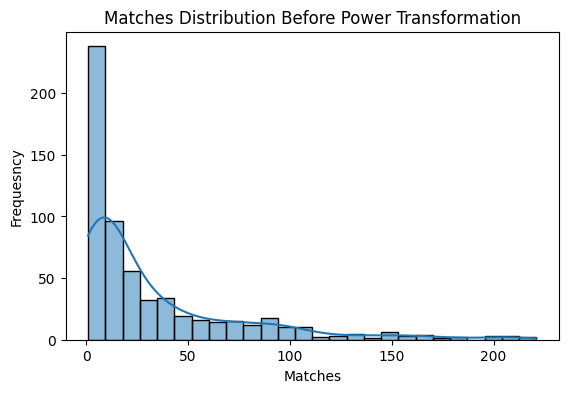

In [6]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(df['matches'], kde=True)
plt.title("Matches Distribution Before Power Transformation")
plt.xlabel("Matches")
plt.ylabel("Frequesncy")

plt.show()

In [7]:
pt = PowerTransformer(method = "yeo-johnson")

df["matches_power"] = pt.fit_transform(df[['matches']].astype(int)) 

print(pt.lambdas_)

[-0.04910141]


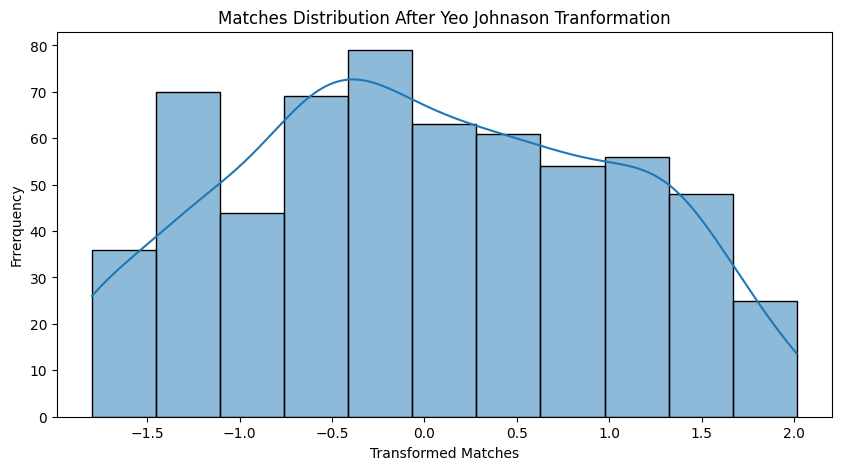

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(df['matches_power'], kde=True)
plt.title("Matches Distribution After Yeo Johnason Tranformation")
plt.xlabel("Transformed Matches")
plt.ylabel("Frrerquency")
plt.show()

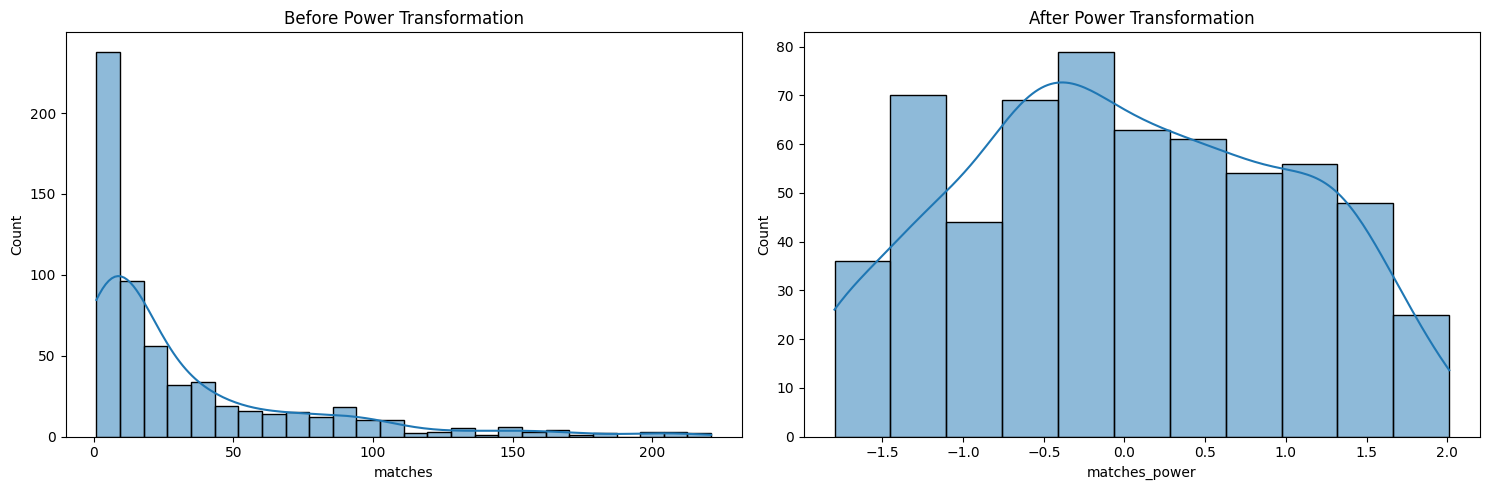

In [9]:
fig , ax = plt.subplots(1,2, figsize=(15,5))

sns.histplot(df['matches'], kde = True, ax = ax[0])
ax[0].set_title("Before Power Transformation")

sns.histplot(df['matches_power'], kde=True, ax=ax[1])
ax[1].set_title("After Power Transformation")

plt.tight_layout()
plt.show()

In [10]:
pt1 = PowerTransformer(method="box-cox")

df["balls_faced_transformed"] = pt1.fit_transform(df[["balls_faced"]])
print(pt1.lambdas_)

[0.00040026]


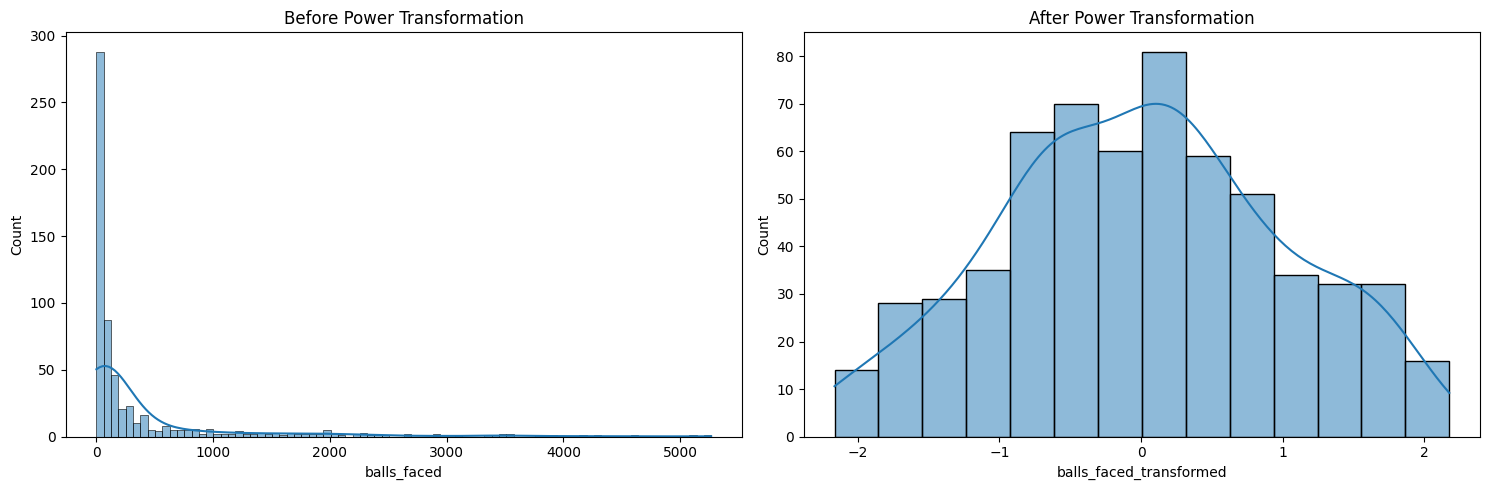

In [11]:
fig , ax = plt.subplots(1,2, figsize=(15,5))

sns.histplot(df['balls_faced'], kde = True, ax = ax[0])
ax[0].set_title("Before Power Transformation")

sns.histplot(df['balls_faced_transformed'], kde=True, ax=ax[1])
ax[1].set_title("After Power Transformation")

plt.tight_layout()
plt.show()

## Binning

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("class_ipl_22-26_dataset.csv")

In [13]:
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."


In [14]:
X = df[["team1_runs"]]
X.head()

,team1_runs
0,131
1,177
2,205
3,158
4,210


In [17]:
bins = [0,120,160,200, df['team1_runs'].max()]

labels = ['Low', "Medium", 'High', "Very High"]

df['Runs_Category'] = pd.cut(
    df['team1_runs'],
    bins = bins,
    labels = labels,
    include_lowest = True
)

df[['team1_runs', 'Runs_Category']].head(10)

,team1_runs,Runs_Category
0,131,Medium
1,177,High
2,205,Very High
3,158,Medium
4,210,Very High
5,128,Medium
6,210,Very High
7,137,Medium
8,171,High
9,193,High


In [20]:
df['Runs_Category'].value_counts().sort_index()

Runs_Category
Low           13
Medium        77
High         148
Very High    129
Name: count, dtype: int64

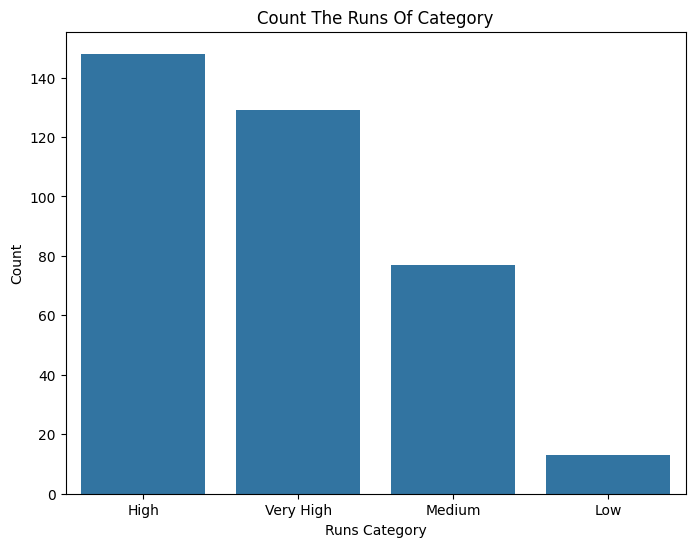

In [24]:
plt.figure(figsize=(8,6))
sns.countplot(x='Runs_Category', data=df, order=df['Runs_Category'].value_counts().index)
plt.title("Count The Runs Of Category")
plt.xlabel("Runs Category")
plt.ylabel("Count")
plt.show()

## Binarization

In [25]:
from sklearn.preprocessing import Binarizer

In [26]:
binarizer = Binarizer(threshold=160)

In [28]:
X_binary = binarizer.fit_transform(X)

X_binary = pd.DataFrame(X_binary, columns = ['team1_runs'])

X_binary.head()

,team1_runs
0,0
1,1
2,1
3,0
4,1


In [30]:
comparision = pd.DataFrame({
    "Original": X['team1_runs'],
    "Binarized" : X_binary['team1_runs']
})

comparision.head(10)

,Original,Binarized
0,131,0
1,177,1
2,205,1
3,158,0
4,210,1
5,128,0
6,210,1
7,137,0
8,171,1
9,193,1


In [31]:
comparision['Binarized'].value_counts()

Binarized
1    277
0     90
Name: count, dtype: int64

C:\Users\prajy\AppData\Local\Temp\ipykernel_21884\3957286239.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='team1_runs', data=X_binary, palette='viridis')


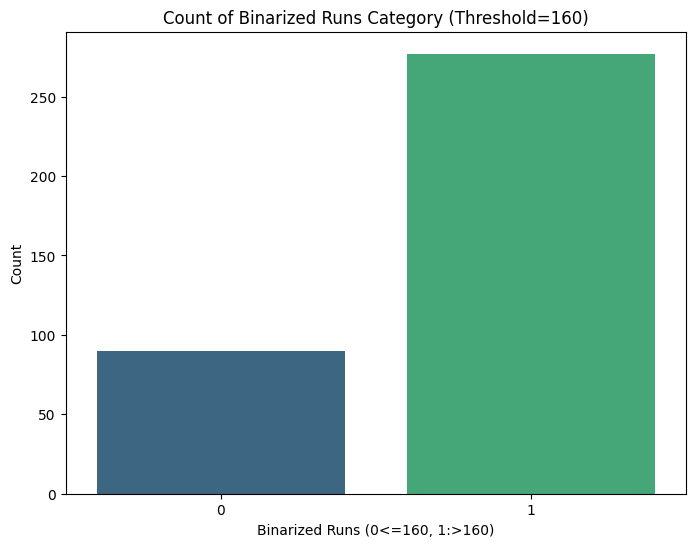

In [34]:
plt.figure(figsize=(8,6))
sns.countplot(x='team1_runs', data=X_binary, palette='viridis')
plt.title("Count of Binarized Runs Category (Threshold=160)")
plt.xlabel("Binarized Runs (0<=160, 1:>160)")
plt.ylabel("Count")

plt.xticks(ticks=[0,1], labels=['0','1'])
plt.show()

## Column Transformer

In [35]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("class_ipl_22-26_dataset.csv")

In [36]:
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."


In [37]:
X = df[['team1_runs', 'toss_decision', 'team1_wickets', 'win_by_wickets']]

X.head()

,team1_runs,toss_decision,team1_wickets,win_by_wickets
0,131,field,5,6
1,177,field,5,4
2,205,field,2,5
3,158,field,6,5
4,210,field,6,0


In [40]:
from sklearn.pipeline import Pipeline

transformer = ColumnTransformer(

    transformers=[
        ('num', SimpleImputer(strategy='mean'),['team1_runs']),

        ('scale', StandardScaler(), ['team1_wickets']),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="most_frequent")),
            ('encoder', OneHotEncoder()) ]),
         ['toss_decision']),

        ('detail', 'passthrough', ['win_by_wickets'])
    ]
)

In [51]:
print(transformer.get_feature_names_out())

['num__team1_runs' 'scale__team1_wickets' 'cat__toss_decision_bat'
 'cat__toss_decision_field' 'detail__win_by_wickets']


In [48]:
X_transformed = transformer.fit_transform(X)

print(type(X_transformed))

X_transformed = pd.DataFrame(X_transformed, columns=['team1_runs', 'team1_wickets','toss_decision_bat', 'toss_decision_field', 'win_by_wickets' ])
X_transformed

<class 'numpy.ndarray'>


,team1_runs,team1_wickets,toss_decision_bat,toss_decision_field,win_by_wickets
0,131.0,-0.572377,0.0,1.0,6.0
1,177.0,-0.572377,0.0,1.0,4.0
2,205.0,-1.954365,0.0,1.0,5.0
3,158.0,-0.111714,0.0,1.0,5.0
4,210.0,-0.111714,0.0,1.0,0.0
...,...,...,...,...,...
362,203.0,-0.572377,0.0,1.0,0.0
363,254.0,-0.572377,0.0,1.0,0.0
364,243.0,0.809612,0.0,1.0,0.0
365,214.0,-0.111714,1.0,0.0,7.0


In [52]:
print("Original Shape : ", X.shape)
print("Transformed Shape : ", X_transformed.shape)

Original Shape :  (367, 4)
Transformed Shape :  (367, 5)
